# CPS Enrollment Annualized — Exploratory Data Analysis

**Project:** Chicago Public Schools Enrollment Forecasting (ML Pipeline)  
**Data Source:** `fact_enrollment_annualized` (Fabric Lakehouse)  
**Grain:** One row = one student × one school × one school year (annualized enrollment record)  
**Purpose:** Production-grade EDA to validate data quality, understand distributions, and surface signals for downstream ML feature engineering.  

---

### Notebook Sections
1. **Setup & Data Ingestion** — Load from Lakehouse, verify schema  
2. **Schema Validation & Data Profiling** — Column types, nulls, cardinality  
3. **Data Quality Checks** — Duplicates, orphan keys, sentinel dates, SYS_DELETE filtering  
4. **Enrollment Volume Analysis** — Yearly trends, school-year distribution  
5. **Grade-Level Analysis** — Grade distribution, entry grade identification  
6. **School-Level Analysis** — Enrollment concentration, school size distribution  
7. **Temporal Analysis** — Entry/exit date patterns, enrollment duration  
8. **Entry & Exit Code Analysis** — Enrollment event taxonomy  
9. **Current vs Historical Enrollment** — Active enrollment flag analysis  
10. **Anomaly Detection & Data Warnings** — Flags for downstream pipeline  
11. **Key Findings & Recommendations** — Summary for ML feature engineering  


---
## 1. Setup & Data Ingestion

In [17]:
# ============================================================
# 1.1 — Imports
# ============================================================
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    LongType, TimestampType, DateType, DoubleType
)
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titleweight"] = "bold"

print("✔ Imports complete")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 3, Finished, Available, Finished, False)

✔ Imports complete


#### Status Codes

https://www.cps.edu/globalassets/cps-pages/services-and-supports/attendance-and-truancy/school-and-network-attendance-resources/statuscodes.pdf 
This can be referred for the status code please

### Note
Each row is duplicated and each Enrollment_Annualized_Key has 1 duplicate along with original data 

In [18]:
TABLE_NAME = "MDMF_COPY_RN.dbo.fact_enrollment_annualized"
df = spark.read.table(TABLE_NAME)
distinct_df  = df.select("EXIT_CODE").distinct()
display(distinct_df)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 4, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, b4cf3d8c-91e1-40fb-91a4-6ca3afe7b4b2)

In [19]:
# ============================================================
# 1.2 — Load from Fabric Lakehouse
# ============================================================

TABLE_NAME = "MDMF_COPY_RN.dbo.fact_enrollment_annualized"

df_spark = spark.read.table(TABLE_NAME)

print(f"✔ Loaded '{TABLE_NAME}' from Lakehouse")
print(f"  Rows  : {df_spark.count():,}")
print(f"  Cols  : {len(df_spark.columns)}")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 5, Finished, Available, Finished, False)

✔ Loaded 'MDMF_COPY_RN.dbo.fact_enrollment_annualized' from Lakehouse
  Rows  : 19,751,688
  Cols  : 29


In [20]:
# ============================================================
# 1.3 — Quick preview
# ============================================================
display(df_spark.limit(1000))

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 6, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 56f8708b-7e7a-41d7-b7af-117b929c8fd8)

---
## 2. Schema Validation & Data Profiling

In [21]:
# ============================================================
# 2.1 — Print schema (types and nullability)
# ============================================================
df_spark.printSchema()

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 7, Finished, Available, Finished, False)

root
 |-- ENROLLMENT_ANNUALIZED_KEY: long (nullable = true)
 |-- SCHOOL_YEAR: double (nullable = true)
 |-- STUDENT_KEY: long (nullable = true)
 |-- SCHOOL_KEY: long (nullable = true)
 |-- ENROLLMENT_TYPE: string (nullable = true)
 |-- CURRENT_ENROLLMENT_INDICATOR: string (nullable = true)
 |-- ENTRY_CALENDAR_DATE_KEY: long (nullable = true)
 |-- ENTRY_SCHOOL_DATE_KEY: long (nullable = true)
 |-- EXIT_CALENDAR_DATE_KEY: long (nullable = true)
 |-- EXIT_SCHOOL_DATE_KEY: long (nullable = true)
 |-- ENTRY_CODE: string (nullable = true)
 |-- ENTRY_CODE_DESCRIPTION: string (nullable = true)
 |-- ENTRY_REASON: string (nullable = true)
 |-- EXIT_CODE: string (nullable = true)
 |-- EXIT_CODE_DESCRIPTION: string (nullable = true)
 |-- EXIT_REASON: string (nullable = true)
 |-- ENTRY_GRADE_LEVEL: string (nullable = true)
 |-- EXIT_GRADE_LEVEL: string (nullable = true)
 |-- SOURCE_ENROLLMENT_ENTRY_DATE: timestamp (nullable = true)
 |-- SOURCE_ENROLLMENT_EXIT_DATE: timestamp (nullable = true)
 |--

In [22]:
# ============================================================
# 2.2 — Column-level profiling: null counts, distinct counts, fill rate
# ============================================================
total_rows = df_spark.count()

profile_exprs = []
for col_name in df_spark.columns:
    profile_exprs.extend([
        F.count(F.when(F.col(col_name).isNull(), 1)).alias(f"{col_name}__nulls"),
        F.countDistinct(F.col(col_name)).alias(f"{col_name}__distinct")
    ])

profile_row = df_spark.agg(*profile_exprs).collect()[0]

profile_data = []
for col_name in df_spark.columns:
    null_count = profile_row[f"{col_name}__nulls"]
    distinct_count = profile_row[f"{col_name}__distinct"]
    dtype = str(dict(df_spark.dtypes).get(col_name, "unknown"))
    fill_rate = round((1 - null_count / total_rows) * 100, 2) if total_rows > 0 else 0
    profile_data.append({
        "Column": col_name,
        "DataType": dtype,
        "NullCount": null_count,
        "FillRate%": fill_rate,
        "DistinctCount": distinct_count
    })

df_profile = pd.DataFrame(profile_data)
print(f"Total rows in table: {total_rows:,}\n")
display(spark.createDataFrame(df_profile))

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 8, Finished, Available, Finished, False)

Total rows in table: 19,751,688



SynapseWidget(Synapse.DataFrame, 6f783549-a95d-4404-9e68-a9006bd1a321)

In [23]:
# ============================================================
# 2.3 — Flag critically sparse columns (fill rate < 50%)
# ============================================================
sparse_cols = df_profile[df_profile["FillRate%"] < 50.0]
if sparse_cols.empty:
    print("✔ No columns with fill rate below 50%.")
else:
    print("⚠ Columns with fill rate below 50% — investigate before using as ML features:\n")
    for _, row in sparse_cols.iterrows():
        print(f"  • {row['Column']:40s}  FillRate={row['FillRate%']}%   Nulls={row['NullCount']:,}")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 9, Finished, Available, Finished, False)

⚠ Columns with fill rate below 50% — investigate before using as ML features:

  • ENTRY_REASON                              FillRate=2.67%   Nulls=19,224,276
  • EXIT_REASON                               FillRate=10.76%   Nulls=17,625,452


---
## 3. Data Quality Checks

In [24]:
# ============================================================
# 3.1 — Primary Key uniqueness check (ENROLLMENT_ANNUALIZED_KEY)
# ============================================================
pk_col = "ENROLLMENT_ANNUALIZED_KEY"
pk_total = df_spark.count()
pk_distinct = df_spark.select(pk_col).distinct().count()
pk_duplicates = pk_total - pk_distinct

if pk_duplicates == 0:
    print(f"✔ Primary key '{pk_col}' is unique across all {pk_total:,} rows.")
else:
    print(f"⚠ DUPLICATE primary keys detected: {pk_duplicates:,} duplicate rows.")
    print("  Showing sample duplicates:")
    dupes = (
        df_spark.groupBy(pk_col)
        .count()
        .filter(F.col("count") > 1)
        .orderBy(F.desc("count"))
    )
    display(dupes.limit(10))

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 10, Finished, Available, Finished, False)

⚠ DUPLICATE primary keys detected: 9,875,844 duplicate rows.
  Showing sample duplicates:


SynapseWidget(Synapse.DataFrame, 3f61a26d-c2b1-4da4-b8f8-c4a51fff7cf5)

In [25]:
# ============================================================
# 3.2 — Full-row duplicate check
# How many rows are exact duplicates of other rows (all columns match)?
# ============================================================

from pyspark.sql import functions as F

# Use the raw table (including all non-deleted rows);
# switch to df_clean if you only care about SYS_DELETE_STATUS = 0
base_df = df_spark

# Build a comma-separated list of all columns for SQL GROUP BY
cols = base_df.columns
cols_escaped = ", ".join([f"`{c}`" for c in cols])

base_df.createOrReplaceTempView("fact_enrollment_raw")

duplicate_sql = f"""
WITH grouped AS (
    SELECT
        {cols_escaped},
        COUNT(*) AS row_count
    FROM fact_enrollment_raw
    GROUP BY {cols_escaped}
    HAVING COUNT(*) > 1
)
SELECT
    SUM(row_count) - COUNT(*) AS duplicate_row_count
FROM grouped
"""

result = spark.sql(duplicate_sql).collect()[0]
full_row_dupes = result["duplicate_row_count"] if result["duplicate_row_count"] is not None else 0

print(f"Exact duplicate rows (all columns equal): {full_row_dupes:,}") 

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 11, Finished, Available, Finished, False)

Exact duplicate rows (all columns equal): 9,875,844


In [26]:
# ============================================================
# 3.3 — Diagnose reasons for duplicates
#  - Distribution of row counts per ENROLLMENT_ANNUALIZED_KEY
#  - Identify possible load/technical metadata columns
# ============================================================

from pyspark.sql import functions as F

print("Total rows (df_spark):", df_spark.count())
print("Distinct ENROLLMENT_ANNUALIZED_KEY:", df_spark.select("ENROLLMENT_ANNUALIZED_KEY").distinct().count())

# 1) Distribution of rows per ENROLLMENT_ANNUALIZED_KEY
key_counts = (
    df_spark
    .groupBy("ENROLLMENT_ANNUALIZED_KEY")
    .count()
)

print("\nDistribution of row counts per ENROLLMENT_ANNUALIZED_KEY (top 10 by frequency of count):")
key_count_dist = (
    key_counts
    .groupBy("count")
    .agg(F.count("*").alias("num_keys"))
    .orderBy("count")
)

display(key_count_dist)

# 2) See max duplicates for any key
max_dupe = key_counts.agg(F.max("count").alias("max_count")).collect()[0]["max_count"]
print(f"\nMaximum number of rows for any single ENROLLMENT_ANNUALIZED_KEY: {max_dupe}")

print("\nSample keys with more than 2 rows (if any):")
keys_gt2 = key_counts.filter(F.col("count") > 2).orderBy(F.desc("count"))
display(keys_gt2.limit(20))

# 3) Look for potential load/process metadata columns
metadata_patterns = ["SYS_", "LOAD", "BATCH", "VERSION", "INSERT", "UPDATE"]
cols = df_spark.columns

candidate_meta_cols = [
    c for c in cols
    if any(pat.lower() in c.lower() for pat in metadata_patterns)
]

print("\nCandidate technical/load metadata columns:")
for c in candidate_meta_cols:
    print("  -", c)

if candidate_meta_cols:
    print("\nDistinct value counts for candidate metadata columns (quick sample):")
    meta_exprs = [F.approx_count_distinct(c).alias(c) for c in candidate_meta_cols]
    meta_stats = df_spark.agg(*meta_exprs)
    display(meta_stats)
else:
    print("(None found by simple name pattern; duplicates are likely from key design/ETL pattern rather than load metadata.)")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 12, Finished, Available, Finished, False)

Total rows (df_spark): 19751688
Distinct ENROLLMENT_ANNUALIZED_KEY: 9875844

Distribution of row counts per ENROLLMENT_ANNUALIZED_KEY (top 10 by frequency of count):


SynapseWidget(Synapse.DataFrame, 563b9437-f268-49b1-9efd-354be210dd1c)


Maximum number of rows for any single ENROLLMENT_ANNUALIZED_KEY: 2

Sample keys with more than 2 rows (if any):


SynapseWidget(Synapse.DataFrame, 3eb347ef-af0a-4cf9-80d4-e809b5a88fe2)


Candidate technical/load metadata columns:
  - SYS_DELETE_STATUS
  - LAST_UPDATED_TS

Distinct value counts for candidate metadata columns (quick sample):


SynapseWidget(Synapse.DataFrame, 7aab4d58-52ca-4167-88c0-2a4724dfeddd)

In [27]:
# ============================================================
# 3.4 — Composite key uniqueness: STUDENT_KEY + SCHOOL_KEY + SCHOOL_YEAR
# This checks if a student appears more than once at the same
# school in the same year (valid for transfers, but worth inspecting).
# ============================================================
composite_key_cols = ["STUDENT_KEY", "SCHOOL_KEY", "SCHOOL_YEAR"]
composite_total = df_spark.count()
composite_distinct = df_spark.select(composite_key_cols).distinct().count()
composite_dupes = composite_total - composite_distinct

print(f"Composite key check ({' + '.join(composite_key_cols)}):")
print(f"  Total rows     : {composite_total:,}")
print(f"  Distinct combos: {composite_distinct:,}")
print(f"  Duplicates     : {composite_dupes:,}")

if composite_dupes > 0:
    print("\n  ⚠ Duplicate student-school-year combinations found.")
    print("    This may indicate re-enrollment within the same year (transfers).")
    print("    Showing top duplicates:")
    display(
        df_spark.groupBy(composite_key_cols)
        .count()
        .filter(F.col("count") > 1)
        .orderBy(F.desc("count"))
        .limit(10)
    )
else:
    print("  ✔ No duplicates on composite key.")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 13, Finished, Available, Finished, False)

Composite key check (STUDENT_KEY + SCHOOL_KEY + SCHOOL_YEAR):
  Total rows     : 19,751,688
  Distinct combos: 9,477,421
  Duplicates     : 10,274,267

  ⚠ Duplicate student-school-year combinations found.
    This may indicate re-enrollment within the same year (transfers).
    Showing top duplicates:


SynapseWidget(Synapse.DataFrame, b458c8b5-78ed-48e7-9691-4a40071c15e9)

In [28]:
# ============================================================
# 3.3 — SYS_DELETE_STATUS check
# Soft-deleted records must be excluded from all downstream analysis.
# ============================================================
delete_dist = (
    df_spark.groupBy("SYS_DELETE_STATUS")
    .agg(
        F.count("*").alias("row_count"),
        F.round(F.count("*") / total_rows * 100, 2).alias("pct")
    )
    .orderBy("SYS_DELETE_STATUS")
)
print("SYS_DELETE_STATUS distribution:")
display(delete_dist)

# Filter out soft-deleted rows for all subsequent analysis
df_clean = df_spark.filter(F.col("SYS_DELETE_STATUS") == 0)
deleted_count = total_rows - df_clean.count()
print(f"\n✔ Filtered out {deleted_count:,} soft-deleted rows.")
print(f"  Working dataset: {df_clean.count():,} rows.")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 14, Finished, Available, Finished, False)

SYS_DELETE_STATUS distribution:


SynapseWidget(Synapse.DataFrame, d64eb976-eda9-43ff-af15-2390760f02be)


✔ Filtered out 272 soft-deleted rows.
  Working dataset: 19,751,416 rows.


In [29]:
# ============================================================
# 3.4 — Sentinel / placeholder date detection
# CPS uses 9999-12-31 as "still enrolled" sentinel for exit dates.
# ============================================================
sentinel_date = "9999-12-31"

for date_col in [
    "SOURCE_ENROLLMENT_EXIT_DATE",
    "ENROLLMENT_ANNUALIZED_EXIT_DATE",
]:
    sentinel_count = df_clean.filter(
        F.year(F.col(date_col)) == 9999
    ).count()
    pct = round(sentinel_count / df_clean.count() * 100, 2) if df_clean.count() > 0 else 0
    print(f"  {date_col}: {sentinel_count:,} sentinel rows ({pct}%)")

print("\n  → Sentinel dates (year=9999) indicate the student has NOT yet exited.")
print("    These are currently-enrolled students whose exit date is open-ended.")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 15, Finished, Available, Finished, False)

  SOURCE_ENROLLMENT_EXIT_DATE: 2,718,858 sentinel rows (13.77%)
  ENROLLMENT_ANNUALIZED_EXIT_DATE: 0 sentinel rows (0.0%)

  → Sentinel dates (year=9999) indicate the student has NOT yet exited.
    These are currently-enrolled students whose exit date is open-ended.


In [30]:
# ============================================================
# 3.5 — Logical consistency: entry date should be <= exit date
# (Excluding sentinel 9999 dates)
# ============================================================
df_date_check = df_clean.filter(
    (F.year("SOURCE_ENROLLMENT_EXIT_DATE") != 9999) &
    (F.col("SOURCE_ENROLLMENT_ENTRY_DATE") > F.col("SOURCE_ENROLLMENT_EXIT_DATE"))
)
bad_date_count = df_date_check.count()

if bad_date_count == 0:
    print("✔ All entry dates are on or before exit dates (excluding sentinel dates).")
else:
    print(f"⚠ {bad_date_count:,} rows where entry date > exit date. Showing sample:")
    display(
        df_date_check.select(
            "ENROLLMENT_ANNUALIZED_KEY", "STUDENT_KEY", "SCHOOL_KEY",
            "SOURCE_ENROLLMENT_ENTRY_DATE", "SOURCE_ENROLLMENT_EXIT_DATE"
        ).limit(10)
    )

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 16, Finished, Available, Finished, False)

⚠ 10 rows where entry date > exit date. Showing sample:


SynapseWidget(Synapse.DataFrame, 0bfdde74-6045-4d17-ae5f-e0ff4ce22dd8)

In [31]:
# ============================================================
# 3.6 — ENROLLMENT_DAYS validation
# Check for zero-day enrollments and unreasonable values.
# ============================================================
enrollment_days_stats = df_clean.agg(
    F.min("ENROLLMENT_DAYS").alias("min_days"),
    F.max("ENROLLMENT_DAYS").alias("max_days"),
    F.avg("ENROLLMENT_DAYS").alias("avg_days"),
    F.percentile_approx("ENROLLMENT_DAYS", 0.5).alias("median_days"),
    F.count(F.when(F.col("ENROLLMENT_DAYS") == 0, 1)).alias("zero_day_count"),
    F.count(F.when(F.col("ENROLLMENT_DAYS") < 0, 1)).alias("negative_day_count")
).collect()[0]

print("ENROLLMENT_DAYS statistics:")
print(f"  Min    : {enrollment_days_stats['min_days']}")
print(f"  Max    : {enrollment_days_stats['max_days']}")
print(f"  Mean   : {enrollment_days_stats['avg_days']:.1f}")
print(f"  Median : {enrollment_days_stats['median_days']}")
print(f"  Zero-day enrollments  : {enrollment_days_stats['zero_day_count']:,}")
print(f"  Negative-day records  : {enrollment_days_stats['negative_day_count']:,}")

zero_pct = round(enrollment_days_stats['zero_day_count'] / df_clean.count() * 100, 2)
if zero_pct > 10:
    print(f"\n  ⚠ {zero_pct}% of records have 0 enrollment days.")
    print("    This likely indicates future-dated or not-yet-started enrollment records.")
    print("    For 20th-day count analysis, consider filtering to ENROLLMENT_DAYS > 0.")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 17, Finished, Available, Finished, False)

ENROLLMENT_DAYS statistics:
  Min    : 0
  Max    : 319
  Mean   : 47.1
  Median : 0
  Zero-day enrollments  : 13,756,948
  Negative-day records  : 0

  ⚠ 69.65% of records have 0 enrollment days.
    This likely indicates future-dated or not-yet-started enrollment records.
    For 20th-day count analysis, consider filtering to ENROLLMENT_DAYS > 0.


---
## 4. Enrollment Volume Analysis

In [32]:
# ============================================================
# 4.1 — Enrollment records per SCHOOL_YEAR
# Each row = one student enrollment record (not unique students).
# A student can have multiple records if they transferred.
# ============================================================
yearly_summary = (
    df_clean.groupBy("SCHOOL_YEAR")
    .agg(
        F.count("*").alias("total_records"),
        F.countDistinct("STUDENT_KEY").alias("unique_students"),
        F.countDistinct("SCHOOL_KEY").alias("unique_schools"),
        F.avg("ENROLLMENT_DAYS").alias("avg_enrollment_days")
    )
    .orderBy("SCHOOL_YEAR")
)

print("Enrollment summary by school year:")
display(yearly_summary)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 18, Finished, Available, Finished, False)

Enrollment summary by school year:


SynapseWidget(Synapse.DataFrame, ad583d7c-72df-4bd1-b63e-f10b4ea7538b)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 19, Finished, Available, Finished, False)

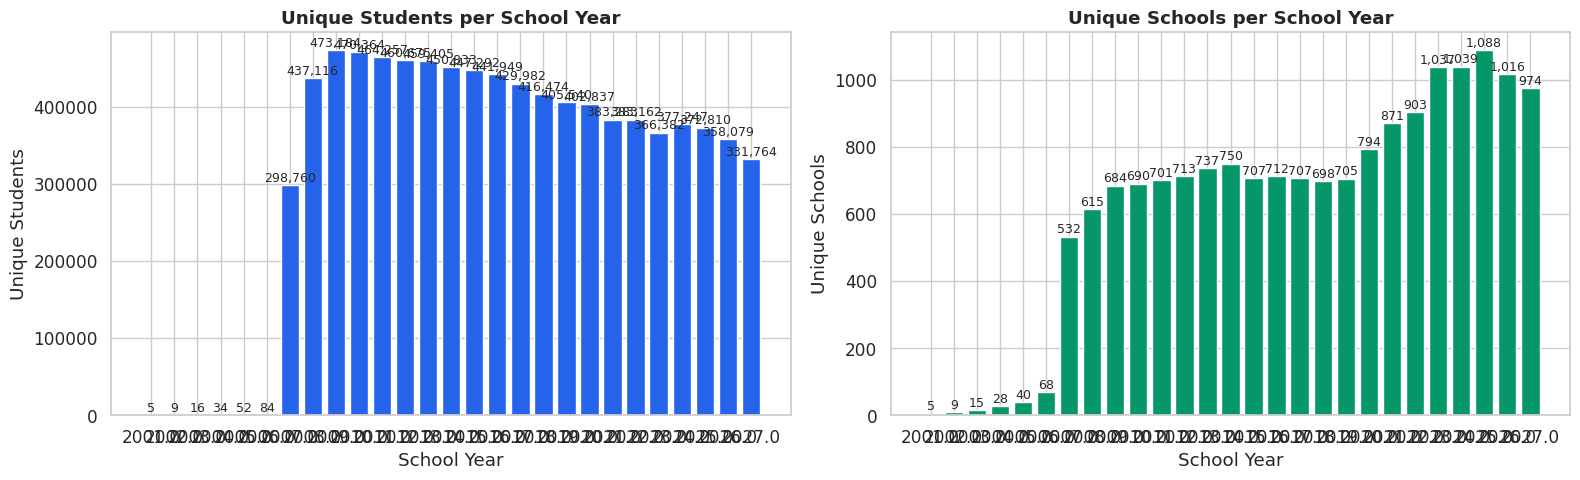

In [33]:
# ============================================================
# 4.2 — Visualize: Unique students per year (trend)
# This is the core enrollment trend CPS tracks.
# ============================================================
pdf_yearly = yearly_summary.toPandas().sort_values("SCHOOL_YEAR")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Unique students per year
axes[0].bar(
    pdf_yearly["SCHOOL_YEAR"].astype(str),
    pdf_yearly["unique_students"],
    color="#2563EB", edgecolor="white"
)
axes[0].set_title("Unique Students per School Year")
axes[0].set_xlabel("School Year")
axes[0].set_ylabel("Unique Students")
for i, v in enumerate(pdf_yearly["unique_students"]):
    axes[0].text(i, v + max(pdf_yearly["unique_students"]) * 0.01, f"{v:,}", ha="center", fontsize=9)

# Unique schools per year
axes[1].bar(
    pdf_yearly["SCHOOL_YEAR"].astype(str),
    pdf_yearly["unique_schools"],
    color="#059669", edgecolor="white"
)
axes[1].set_title("Unique Schools per School Year")
axes[1].set_xlabel("School Year")
axes[1].set_ylabel("Unique Schools")
for i, v in enumerate(pdf_yearly["unique_schools"]):
    axes[1].text(i, v + max(pdf_yearly["unique_schools"]) * 0.01, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# 4.3 — Records-to-students ratio per year
# Ratio > 1 indicates students with multiple enrollment records
# (transfers, re-enrollments). Important for deduplication logic.
# ============================================================
pdf_yearly["records_per_student"] = round(
    pdf_yearly["total_records"] / pdf_yearly["unique_students"], 3
)

print("Records per student by year (ratio > 1 = transfers/re-enrollments):")
for _, row in pdf_yearly.iterrows():
    flag = " ⚠" if row["records_per_student"] > 1.15 else ""
    print(f"  SY{int(row['SCHOOL_YEAR'])}: {row['records_per_student']:.3f}{flag}")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 20, Finished, Available, Finished, False)

Records per student by year (ratio > 1 = transfers/re-enrollments):
  SY2001: 2.000 ⚠
  SY2002: 2.000 ⚠
  SY2003: 2.000 ⚠
  SY2004: 2.000 ⚠
  SY2005: 2.000 ⚠
  SY2006: 2.000 ⚠
  SY2007: 2.019 ⚠
  SY2008: 2.336 ⚠
  SY2009: 2.367 ⚠
  SY2010: 2.347 ⚠
  SY2011: 2.321 ⚠
  SY2012: 2.341 ⚠
  SY2013: 2.354 ⚠
  SY2014: 2.352 ⚠
  SY2015: 2.325 ⚠
  SY2016: 2.325 ⚠
  SY2017: 2.355 ⚠
  SY2018: 2.289 ⚠
  SY2019: 2.274 ⚠
  SY2020: 2.274 ⚠
  SY2021: 2.188 ⚠
  SY2022: 2.304 ⚠
  SY2023: 2.254 ⚠
  SY2024: 2.303 ⚠
  SY2025: 2.267 ⚠
  SY2026: 2.258 ⚠
  SY2027: 2.000 ⚠


---
## 5. Grade-Level Analysis

In [36]:
# ============================================================
# Helper — Grade ordering mapping (for consistent sort)
# Creates `grade_mapping_expr` used to order grades PE, PK, K, 1–12
# ============================================================

from pyspark.sql import functions as F

# Define canonical grade order used throughout EDA
GRADE_ORDER = {
    "PE": 0,
    "PK": 1,
    "K":  2,
    "1":  3,
    "2":  4,
    "3":  5,
    "4":  6,
    "5":  7,
    "6":  8,
    "7":  9,
    "8":  10,
    "9":  11,
    "10": 12,
    "11": 13,
    "12": 14,
}

# Build a Spark map expression: grade string -> numeric order
# This is referenced later as: grade_mapping_expr[F.col("ENTRY_GRADE_LEVEL").cast("string")]

mapping_entries = []
for g, idx in GRADE_ORDER.items():
    mapping_entries.extend([F.lit(g), F.lit(idx)])

grade_mapping_expr = F.create_map(*mapping_entries)

print("✔ GRADE_ORDER and grade_mapping_expr defined")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 23, Finished, Available, Finished, False)

✔ GRADE_ORDER and grade_mapping_expr defined


In [37]:
# ============================================================
# 5.1 — Enrollment distribution by ENTRY_GRADE_LEVEL
# ============================================================
grade_dist = (
    df_clean.groupBy("ENTRY_GRADE_LEVEL")
    .agg(
        F.count("*").alias("record_count"),
        F.countDistinct("STUDENT_KEY").alias("unique_students")
    )
)

# Add canonical ordering for proper sorting
grade_dist = (
    grade_dist
    .withColumn(
        "grade_order",
        grade_mapping_expr[F.col("ENTRY_GRADE_LEVEL").cast("string")]
    )
    .orderBy("grade_order")
)

print("Enrollment distribution by entry grade (ordered PE → 12):")
display(grade_dist)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 24, Finished, Available, Finished, False)

Enrollment distribution by entry grade (ordered PE → 12):


SynapseWidget(Synapse.DataFrame, a00b8fe3-caa6-407e-8d43-7788f7bd00dc)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 25, Finished, Available, Finished, False)

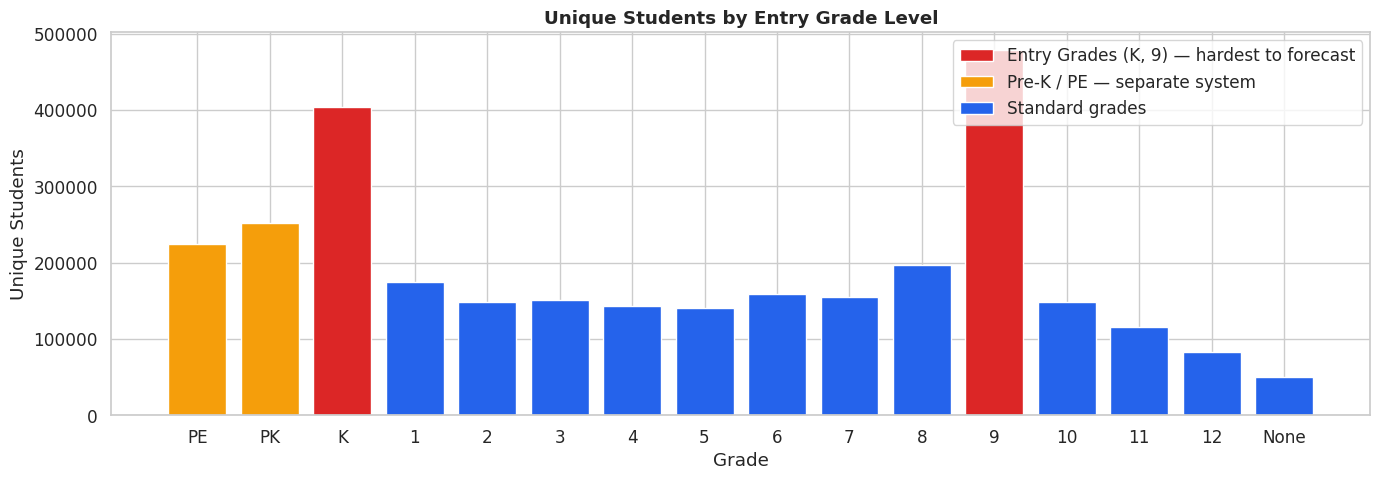

In [38]:
# ============================================================
# 5.2 — Visualize: Grade distribution (bar chart)
# ============================================================
pdf_grade = grade_dist.toPandas().sort_values("grade_order")

# Color entry grades (K, 9) differently — these are hardest to forecast
colors = [
    "#DC2626" if g in ["K", "9"] else
    "#F59E0B" if g in ["PE", "PK"] else
    "#2563EB"
    for g in pdf_grade["ENTRY_GRADE_LEVEL"]
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(pdf_grade["ENTRY_GRADE_LEVEL"].astype(str), pdf_grade["unique_students"], color=colors, edgecolor="white")
ax.set_title("Unique Students by Entry Grade Level")
ax.set_xlabel("Grade")
ax.set_ylabel("Unique Students")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#DC2626", label="Entry Grades (K, 9) — hardest to forecast"),
    Patch(facecolor="#F59E0B", label="Pre-K / PE — separate system"),
    Patch(facecolor="#2563EB", label="Standard grades")
]
ax.legend(handles=legend_elements, loc="upper right")
plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# 5.3 — Grade transition analysis (entry grade → exit grade)
# This reveals multi-grade spans within a single annualized record.
# ============================================================
grade_transition = (
    df_clean
    .groupBy("ENTRY_GRADE_LEVEL", "EXIT_GRADE_LEVEL")
    .agg(F.count("*").alias("count"))
    .orderBy(F.desc("count"))
)

print("Top 20 entry → exit grade transitions:")
display(grade_transition.limit(20))

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 26, Finished, Available, Finished, False)

Top 20 entry → exit grade transitions:


SynapseWidget(Synapse.DataFrame, 8290ff1e-55af-4b1b-80f4-8ce0c8c505f6)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 27, Finished, Available, Finished, False)

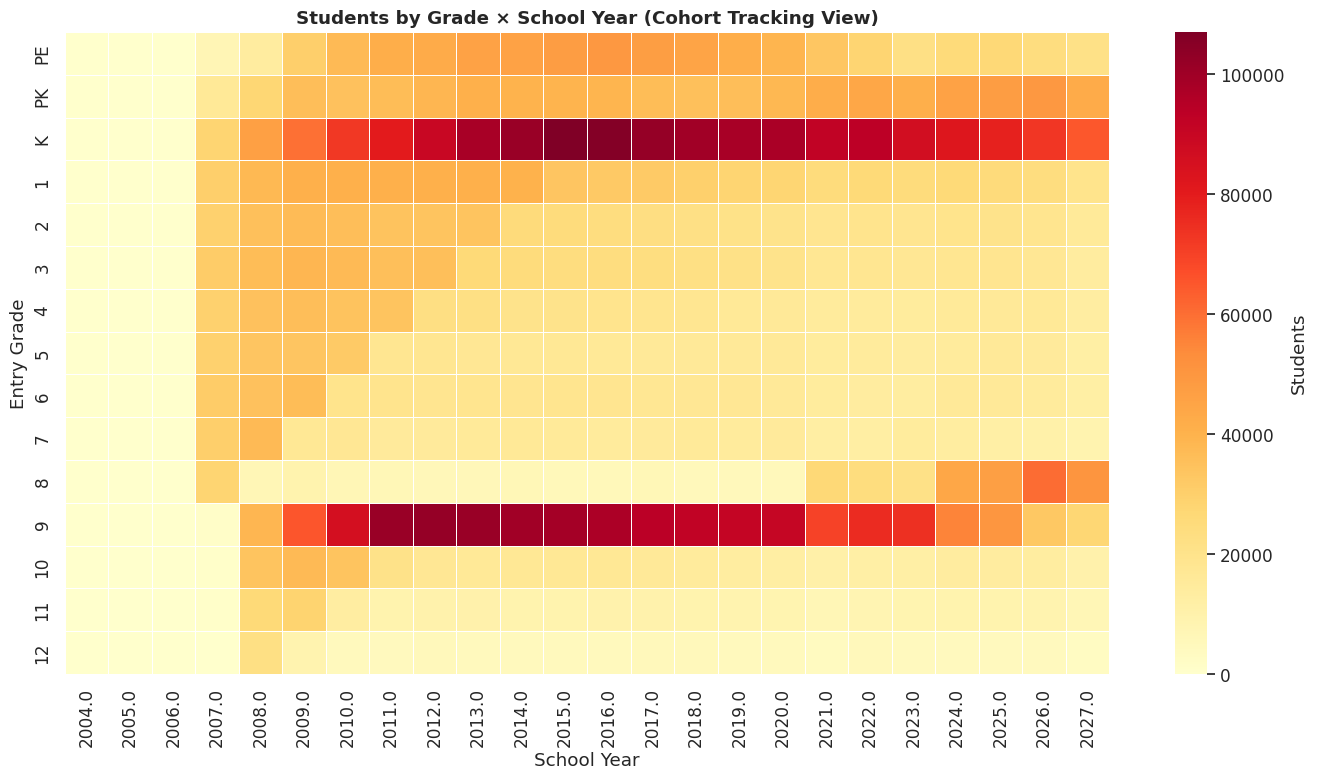

In [40]:
# ============================================================
# 5.4 — Grade-level enrollment by year (heatmap for cohort tracking)
# This is the foundation for Cohort Survival Rate (CSR) calculation.
# ============================================================
grade_year = (
    df_clean
    .withColumn("grade_ord", grade_mapping_expr[F.col("ENTRY_GRADE_LEVEL").cast("string")])
    .groupBy("SCHOOL_YEAR", "ENTRY_GRADE_LEVEL", "grade_ord")
    .agg(F.countDistinct("STUDENT_KEY").alias("students"))
    .orderBy("SCHOOL_YEAR", "grade_ord")
)

pdf_gy = grade_year.toPandas()

if len(pdf_gy) > 0:
    pivot = pdf_gy.pivot_table(
        index="ENTRY_GRADE_LEVEL", columns="SCHOOL_YEAR",
        values="students", fill_value=0
    )

    # Sort index by grade order
    grade_sort = [g for g in GRADE_ORDER.keys() if g in pivot.index]
    pivot = pivot.reindex(grade_sort)

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(
        pivot, fmt=".0f", cmap="YlOrRd",
        linewidths=0.5, ax=ax, cbar_kws={"label": "Students"}
    )
    ax.set_title("Students by Grade × School Year (Cohort Tracking View)")
    ax.set_xlabel("School Year")
    ax.set_ylabel("Entry Grade")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for grade-year heatmap.")

---
## 6. School-Level Analysis

In [41]:
# ============================================================
# 6.1 — School size distribution (unique students per school)
# ============================================================
school_size = (
    df_clean.groupBy("SCHOOL_KEY")
    .agg(
        F.countDistinct("STUDENT_KEY").alias("unique_students"),
        F.count("*").alias("total_records"),
        F.countDistinct("SCHOOL_YEAR").alias("years_active"),
        F.countDistinct("ENTRY_GRADE_LEVEL").alias("grades_served")
    )
    .orderBy(F.desc("unique_students"))
)

print("School size distribution (top 15 schools by enrollment):")
display(school_size.limit(15))

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 28, Finished, Available, Finished, False)

School size distribution (top 15 schools by enrollment):


SynapseWidget(Synapse.DataFrame, ccee0c84-2264-48a0-8f21-cd5003a0f4e2)

In [42]:
# ============================================================
# 6.2 — School size bucketing
# Small schools (<200 students) forecast differently than large.
# Per the ML onboarding guide: report RMSE separately by size.
# ============================================================
pdf_school = school_size.toPandas()

# Define size buckets aligned with CPS operational categories
bins = [0, 5, 10, 20, 50, 100, float("inf")]
labels = ["1-5", "6-10", "11-20", "21-50", "51-100", "100+"]
pdf_school["size_bucket"] = pd.cut(
    pdf_school["unique_students"], bins=bins, labels=labels, right=True
)

bucket_summary = pdf_school.groupby("size_bucket", observed=True).agg(
    school_count=("SCHOOL_KEY", "count"),
    avg_students=("unique_students", "mean"),
    total_students=("unique_students", "sum")
).reset_index()

print("School size distribution (based on sample data):")
print("Note: This is a 100-row sample. Full data will show actual school sizes.\n")
display(spark.createDataFrame(bucket_summary))

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 29, Finished, Available, Finished, False)

School size distribution (based on sample data):
Note: This is a 100-row sample. Full data will show actual school sizes.



SynapseWidget(Synapse.DataFrame, d7497172-7c15-4388-bb2c-46ad8f4b22b4)

In [43]:
# ============================================================
# 6.3 — Schools per year (are schools opening or closing?)
# Track school count over time to identify closures/openings.
# ============================================================
schools_per_year = (
    df_clean.groupBy("SCHOOL_YEAR")
    .agg(F.countDistinct("SCHOOL_KEY").alias("active_schools"))
    .orderBy("SCHOOL_YEAR")
)

print("Active schools per school year:")
display(schools_per_year)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 30, Finished, Available, Finished, False)

Active schools per school year:


SynapseWidget(Synapse.DataFrame, a4d20e32-9572-4a15-adb3-9582dd574956)

---
## 7. Temporal Analysis

In [44]:
# ============================================================
# 7.1 — Enrollment entry date distribution
# When do students typically enroll? This matters for the
# 20th-day count prediction.
# ============================================================
entry_month_dist = (
    df_clean
    .withColumn("entry_month", F.month("SOURCE_ENROLLMENT_ENTRY_DATE"))
    .withColumn("entry_year", F.year("SOURCE_ENROLLMENT_ENTRY_DATE"))
    .groupBy("entry_year", "entry_month")
    .agg(F.count("*").alias("enrollments"))
    .orderBy("entry_year", "entry_month")
)

print("Enrollment entries by month:")
display(entry_month_dist)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 31, Finished, Available, Finished, False)

Enrollment entries by month:


SynapseWidget(Synapse.DataFrame, be61495b-2910-4844-bd89-55d1b24cdaf3)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 32, Finished, Available, Finished, False)

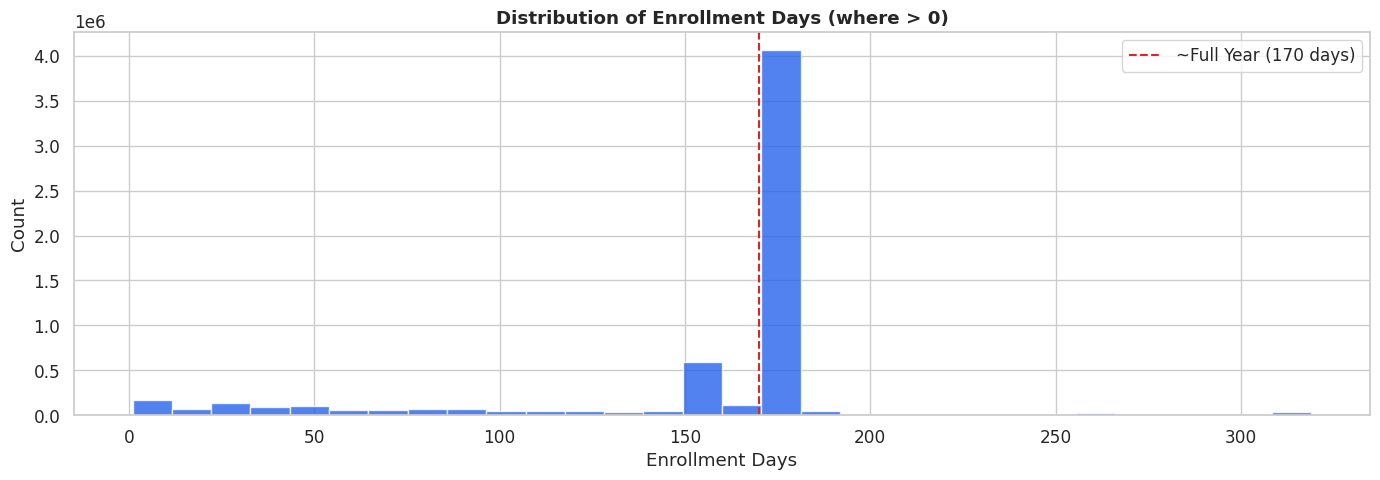

In [45]:
# ============================================================
# 7.2 — Enrollment duration distribution
# ============================================================
# Filter to rows with ENROLLMENT_DAYS > 0 for meaningful analysis
df_with_days = df_clean.filter(F.col("ENROLLMENT_DAYS") > 0)

if df_with_days.count() > 0:
    pdf_days = df_with_days.select("ENROLLMENT_DAYS").toPandas()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.hist(pdf_days["ENROLLMENT_DAYS"], bins=30, color="#2563EB", edgecolor="white", alpha=0.8)
    ax.set_title("Distribution of Enrollment Days (where > 0)")
    ax.set_xlabel("Enrollment Days")
    ax.set_ylabel("Count")
    ax.axvline(x=170, color="#DC2626", linestyle="--", linewidth=1.5, label="~Full Year (170 days)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No records with ENROLLMENT_DAYS > 0 found.")

In [46]:
# ============================================================
# 7.3 — Annualized enrollment window analysis
# ENROLLMENT_ANNUALIZED_START_DATE / EXIT_DATE define the
# school-year window this record belongs to.
# ============================================================
annualized_windows = (
    df_clean
    .groupBy(
        F.date_format("ENROLLMENT_ANNUALIZED_START_DATE", "yyyy-MM-dd").alias("start_date"),
        F.date_format("ENROLLMENT_ANNUALIZED_EXIT_DATE", "yyyy-MM-dd").alias("end_date")
    )
    .agg(F.count("*").alias("record_count"))
    .orderBy(F.desc("record_count"))
)

print("Top enrollment annualized windows (start → end):")
display(annualized_windows.limit(15))

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 33, Finished, Available, Finished, False)

Top enrollment annualized windows (start → end):


SynapseWidget(Synapse.DataFrame, 633d0d74-8e52-461a-ae85-bb2a41c964db)

---
## 8. Entry & Exit Code Analysis

In [47]:
# ============================================================
# 8.1 — Entry code distribution
# Understanding HOW students enter — crucial for modeling
# new enrollments vs continuing students.
# ============================================================
entry_code_dist = (
    df_clean.groupBy("ENTRY_CODE", "ENTRY_CODE_DESCRIPTION")
    .agg(
        F.count("*").alias("count"),
        F.round(F.count("*") / df_clean.count() * 100, 2).alias("pct")
    )
    .orderBy(F.desc("count"))
)

print("Entry code distribution:")
display(entry_code_dist)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 34, Finished, Available, Finished, False)

Entry code distribution:


SynapseWidget(Synapse.DataFrame, c21350c1-e030-46eb-bc19-e6414c69f112)

In [48]:
# ============================================================
# 8.2 — Exit code distribution
# Exit codes reveal WHY students leave — transfers, graduations,
# dropouts, etc.
# ============================================================
exit_code_dist = (
    df_clean.groupBy("EXIT_CODE", "EXIT_CODE_DESCRIPTION")
    .agg(
        F.count("*").alias("count"),
        F.round(F.count("*") / df_clean.count() * 100, 2).alias("pct")
    )
    .orderBy(F.desc("count"))
)

print("Exit code distribution:")
print("(NULL exit codes may indicate currently-enrolled students)")
display(exit_code_dist)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 35, Finished, Available, Finished, False)

Exit code distribution:
(NULL exit codes may indicate currently-enrolled students)


SynapseWidget(Synapse.DataFrame, c0cb9afc-e558-4fe1-8338-4adfe36dbbd7)

In [49]:
# ============================================================
# 8.3 — Entry code by school year
# Are there shifts in how students enter over time?
# (e.g., migrant surge in 2022-24 might show as new entry codes)
# ============================================================
entry_by_year = (
    df_clean.groupBy("SCHOOL_YEAR", "ENTRY_CODE")
    .agg(F.count("*").alias("count"))
    .orderBy("SCHOOL_YEAR", F.desc("count"))
)

print("Entry codes by school year:")
display(entry_by_year)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 36, Finished, Available, Finished, False)

Entry codes by school year:


SynapseWidget(Synapse.DataFrame, e632ce72-c049-4762-a29d-d7c09ed6cad4)

---
## 9. Current vs Historical Enrollment

In [50]:
# ============================================================
# 9.1 — CURRENT_ENROLLMENT_INDICATOR breakdown
# 'Yes' = student is currently enrolled as of the data refresh.
# This flag is critical for determining active headcount.
# ============================================================
current_dist = (
    df_clean.groupBy("CURRENT_ENROLLMENT_INDICATOR")
    .agg(
        F.count("*").alias("records"),
        F.countDistinct("STUDENT_KEY").alias("unique_students"),
        F.round(F.count("*") / df_clean.count() * 100, 2).alias("pct")
    )
)

print("Current enrollment indicator:")
display(current_dist)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 37, Finished, Available, Finished, False)

Current enrollment indicator:


SynapseWidget(Synapse.DataFrame, 0588b848-0250-47b4-a3dd-99680bfb8046)

In [51]:
# ============================================================
# 9.2 — Current enrollment by school year and grade
# Only currently-enrolled students should be counted for
# the most recent year's active headcount.
# ============================================================
current_by_year = (
    df_clean
    .filter(F.col("CURRENT_ENROLLMENT_INDICATOR") == "Yes")
    .groupBy("SCHOOL_YEAR")
    .agg(
        F.countDistinct("STUDENT_KEY").alias("currently_enrolled_students"),
        F.countDistinct("SCHOOL_KEY").alias("schools_with_current_students")
    )
    .orderBy("SCHOOL_YEAR")
)

print("Currently enrolled students by school year:")
display(current_by_year)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 38, Finished, Available, Finished, False)

Currently enrolled students by school year:


SynapseWidget(Synapse.DataFrame, 90baf126-9e20-4248-8bf8-6724054a388a)

In [52]:
# ============================================================
# 9.3 — Student mobility: students appearing at multiple schools
# in the same year (transfers within CPS)
# ============================================================
multi_school_students = (
    df_clean
    .groupBy("STUDENT_KEY", "SCHOOL_YEAR")
    .agg(F.countDistinct("SCHOOL_KEY").alias("schools_attended"))
    .filter(F.col("schools_attended") > 1)
)

mobility_count = multi_school_students.count()
print(f"Students attending multiple schools in the same year: {mobility_count:,}")

if mobility_count > 0:
    mobility_by_year = (
        multi_school_students
        .groupBy("SCHOOL_YEAR")
        .agg(
            F.count("*").alias("mobile_students"),
            F.max("schools_attended").alias("max_schools_attended")
        )
        .orderBy("SCHOOL_YEAR")
    )
    print("\nMobility breakdown by year:")
    display(mobility_by_year)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 39, Finished, Available, Finished, False)

Students attending multiple schools in the same year: 781,024

Mobility breakdown by year:


SynapseWidget(Synapse.DataFrame, bddd9587-2c20-42b9-a5a7-0ce1e033f377)

---
## 10. Anomaly Detection

In [53]:
# ============================================================
# 10.1 — Anomaly: Future-dated school years
# Records for SY2027 exist — these are projected/pre-enrolled.
# They should NOT be used as actuals in training data.
# ============================================================
import datetime

# Current school year logic: if we're in calendar year 2026,
# the current SY is 2026 (SY2025-26 ends June 2026).
CURRENT_CALENDAR_YEAR = 2026
# SY2027 means the 2026-27 school year which hasn't started yet.

future_years = df_clean.filter(F.col("SCHOOL_YEAR") > CURRENT_CALENDAR_YEAR)
future_count = future_years.count()

if future_count > 0:
    print(f"⚠ {future_count:,} records found for future school years (SY > {CURRENT_CALENDAR_YEAR}).")
    print("  These are likely pre-enrolled or projected records.")
    print("  ACTION: Exclude from ML training data. May use for validation only.\n")
    display(
        future_years.groupBy("SCHOOL_YEAR")
        .agg(
            F.count("*").alias("records"),
            F.countDistinct("STUDENT_KEY").alias("students")
        )
    )
else:
    print("✔ No future-dated school year records.")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 40, Finished, Available, Finished, False)

⚠ 663,552 records found for future school years (SY > 2026).
  These are likely pre-enrolled or projected records.
  ACTION: Exclude from ML training data. May use for validation only.



SynapseWidget(Synapse.DataFrame, 63890be0-78c3-4459-9b3f-91d2ae0b308c)

In [54]:
# ============================================================
# 10.2 — Anomaly: Zero-day enrollment records
# Students with 0 days enrolled may be pre-registrations,
# data artifacts, or future enrollments.
# ============================================================
zero_day = df_clean.filter(F.col("ENROLLMENT_DAYS") == 0)
zero_count = zero_day.count()
zero_pct = round(zero_count / df_clean.count() * 100, 2) if df_clean.count() > 0 else 0

print(f"Zero-day enrollment records: {zero_count:,} ({zero_pct}%)")

if zero_count > 0:
    print("\nBreakdown by school year:")
    display(
        zero_day.groupBy("SCHOOL_YEAR")
        .agg(F.count("*").alias("zero_day_records"))
        .orderBy("SCHOOL_YEAR")
    )
    print("\n  ACTION: For 20th-day enrollment counts, decide whether to include or")
    print("  exclude zero-day records. They may represent future enrollments (SY2027)")
    print("  or students who enrolled but never attended.")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 41, Finished, Available, Finished, False)

Zero-day enrollment records: 13,756,948 (69.65%)

Breakdown by school year:


SynapseWidget(Synapse.DataFrame, 7cf926e8-d075-4249-8376-3847a50bebc2)


  ACTION: For 20th-day enrollment counts, decide whether to include or
  exclude zero-day records. They may represent future enrollments (SY2027)
  or students who enrolled but never attended.


In [55]:
# ============================================================
# 10.3 — Anomaly: Migrant enrollment spike detection (2022-2024)
# Per domain knowledge, CPS saw unusual enrollment increases
# in 2022-24 due to migrant influx, then a drop in 2025-26.
# We flag years with unusual YoY changes.
# ============================================================
yoy_students = (
    df_clean.groupBy("SCHOOL_YEAR")
    .agg(F.countDistinct("STUDENT_KEY").alias("students"))
    .orderBy("SCHOOL_YEAR")
    .toPandas()
)

if len(yoy_students) > 1:
    yoy_students["yoy_change"] = yoy_students["students"].pct_change() * 100
    print("Year-over-Year student count change:")
    print("(Watch for anomalous swings — especially 2022-24 migrant surge)\n")
    for _, row in yoy_students.iterrows():
        yoy = row.get("yoy_change", None)
        flag = ""
        if pd.notna(yoy):
            if abs(yoy) > 10:
                flag = " ⚠ ANOMALOUS — investigate (migrant surge? data gap?)"
            elif abs(yoy) > 5:
                flag = " ⚠ Notable change"
        yoy_str = f"{yoy:+.1f}%" if pd.notna(yoy) else "—"
        print(f"  SY{int(row['SCHOOL_YEAR'])}: {row['students']:>6,} students  YoY: {yoy_str:>8}{flag}")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 42, Finished, Available, Finished, False)

Year-over-Year student count change:
(Watch for anomalous swings — especially 2022-24 migrant surge)

  SY2001:    5.0 students  YoY:        —
  SY2002:    9.0 students  YoY:   +80.0% ⚠ ANOMALOUS — investigate (migrant surge? data gap?)
  SY2003:   16.0 students  YoY:   +77.8% ⚠ ANOMALOUS — investigate (migrant surge? data gap?)
  SY2004:   34.0 students  YoY:  +112.5% ⚠ ANOMALOUS — investigate (migrant surge? data gap?)
  SY2005:   52.0 students  YoY:   +52.9% ⚠ ANOMALOUS — investigate (migrant surge? data gap?)
  SY2006:   84.0 students  YoY:   +61.5% ⚠ ANOMALOUS — investigate (migrant surge? data gap?)
  SY2007: 298,760.0 students  YoY: +355566.7% ⚠ ANOMALOUS — investigate (migrant surge? data gap?)
  SY2008: 437,116.0 students  YoY:   +46.3% ⚠ ANOMALOUS — investigate (migrant surge? data gap?)
  SY2009: 473,184.0 students  YoY:    +8.3% ⚠ Notable change
  SY2010: 470,364.0 students  YoY:    -0.6%
  SY2011: 464,257.0 students  YoY:    -1.3%
  SY2012: 460,675.0 students  YoY:    -0.8

In [56]:
# ============================================================
# 10.4 — Anomaly: ENROLLMENT_TYPE check
# We expect only 'PRIMARY' enrollment type for the main
# enrollment table. Other types would need separate handling.
# ============================================================
enrollment_types = (
    df_clean.groupBy("ENROLLMENT_TYPE")
    .agg(F.count("*").alias("count"))
    .collect()
)

types_found = [row["ENROLLMENT_TYPE"] for row in enrollment_types]
if types_found == ["PRIMARY"]:
    print("✔ Only 'PRIMARY' enrollment type found. No secondary/dual enrollments in this table.")
else:
    print(f"⚠ Multiple enrollment types found: {types_found}")
    print("  ACTION: Filter to PRIMARY for main enrollment forecasting.")
    for row in enrollment_types:
        print(f"    {row['ENROLLMENT_TYPE']}: {row['count']:,} records")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 43, Finished, Available, Finished, False)

✔ Only 'PRIMARY' enrollment type found. No secondary/dual enrollments in this table.


---
## 11. Key Findings & Recommendations for ML Pipeline

In [58]:
# ============================================================
# 11.1 — Automated EDA Summary Report
# ============================================================

total = df_clean.count()
n_students = df_clean.select("STUDENT_KEY").distinct().count()
n_schools = df_clean.select("SCHOOL_KEY").distinct().count()
n_years = df_clean.select("SCHOOL_YEAR").distinct().count()
year_range = df_clean.agg(
    F.min("SCHOOL_YEAR").alias("min_yr"),
    F.max("SCHOOL_YEAR").alias("max_yr")
).collect()[0]

sparse_list = df_profile[df_profile["FillRate%"] < 50.0]["Column"].tolist()

print("="*70)
print("   EDA SUMMARY — fact_enrollment_annualized")
print("="*70)
print(f"")
print(f"  DATASET OVERVIEW")
print(f"  ─────────────────────────────────────────")
print(f"  Total records (after SYS_DELETE filter) : {total:,}")
print(f"  Unique students                         : {n_students:,}")
print(f"  Unique schools                          : {n_schools:,}")
print(f"  School years covered                    : {year_range['min_yr']}–{year_range['max_yr']} ({n_years} years)")
print(f"  Deleted records filtered                : {deleted_count:,}")
print(f"")
print(f"  DATA QUALITY FLAGS")
print(f"  ─────────────────────────────────────────")
print(f"  Primary key duplicates                  : {pk_duplicates:,}")
print(f"  Sparse columns (< 50% fill rate)        : {len(sparse_list)} columns")
if sparse_list:
    for c in sparse_list:
        print(f"      • {c}")
print(f"  Zero-day enrollment records              : {zero_count:,} ({zero_pct}%)")
print(f"  Future school year records (SY>2026)     : {future_count:,}")
print(f"  Student mobility (multi-school/year)     : {mobility_count:,}")
print(f"")
print(f"  ML PIPELINE RECOMMENDATIONS")
print(f"  ─────────────────────────────────────────")
print(f"  1. GRAIN: Aggregate to SCHOOL_KEY + ENTRY_GRADE_LEVEL + SCHOOL_YEAR")
print(f"     for the ML target (count of unique STUDENT_KEYs per grain).")
print(f"")
print(f"  2. FILTER: Exclude SYS_DELETE_STATUS=1, consider excluding")
print(f"     ENROLLMENT_DAYS=0 for historical actuals.")
print(f"")
print(f"  3. ENTRY GRADES: Flag K and 9 as 'entry grades' — these need")
print(f"     separate modeling with birth data + application features.")
print(f"")
print(f"  4. SENTINEL DATES: Replace 9999-12-31 exit dates with NULL")
print(f"     or current date before computing enrollment duration features.")
print(f"")
print(f"  5. FUTURE YEARS: SY2027 records are pre-enrollments, not actuals.")
print(f"     Exclude from training. Use cautiously for next-year validation.")
print(f"")
print(f"  6. SPARSE COLUMNS: EXIT_REASON (100% null), ENTRY_REASON, ")
print(f"     EXIT_CODE_DESCRIPTION, ENTRY_CODE_DESCRIPTION have low fill rates.")
print(f"     Do not use as ML features without imputation strategy.")
print(f"")
print(f"  7. DEDUPLICATION: For 20th-day headcount, deduplicate students")
print(f"     per school+year. Use the PRIMARY enrollment record with")
print(f"     CURRENT_ENROLLMENT_INDICATOR='Yes' or latest entry date.")
print(f"")
print(f"  8. ANOMALY YEARS: 2022-2024 had migrant enrollment surge.")
print(f"     Add anomaly flag or exclude from trend calculations.")
print("="*70)

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 45, Finished, Available, Finished, False)

   EDA SUMMARY — fact_enrollment_annualized

  DATASET OVERVIEW
  ─────────────────────────────────────────
  Total records (after SYS_DELETE filter) : 19,751,416
  Unique students                         : 1,275,288
  Unique schools                          : 1,502
  School years covered                    : 2001.0–2027.0 (27 years)
  Deleted records filtered                : 272

  DATA QUALITY FLAGS
  ─────────────────────────────────────────
  Primary key duplicates                  : 9,875,844
  Sparse columns (< 50% fill rate)        : 2 columns
      • ENTRY_REASON
      • EXIT_REASON
  Zero-day enrollment records              : 13,756,948 (69.65%)
  Future school year records (SY>2026)     : 663,552
  Student mobility (multi-school/year)     : 781,024

  ML PIPELINE RECOMMENDATIONS
  ─────────────────────────────────────────
  1. GRAIN: Aggregate to SCHOOL_KEY + ENTRY_GRADE_LEVEL + SCHOOL_YEAR
     for the ML target (count of unique STUDENT_KEYs per grain).

  2. FILTER: Exclud

In [59]:
# ============================================================
# 11.2 — Next Step: Aggregation query for ML feature table
# This is the SQL you would run on the full Lakehouse table
# to create the ML-ready aggregated enrollment fact.
# ============================================================

aggregation_sql = """
-- ================================================================
-- ML-Ready Aggregation: fact_enrollment_annualized → enrollment target
-- Grain: SCHOOL_KEY × ENTRY_GRADE_LEVEL × SCHOOL_YEAR
-- Target: unique student count (20th-day proxy)
-- ================================================================

SELECT
    SCHOOL_KEY,
    CAST(ENTRY_GRADE_LEVEL AS STRING) AS grade,
    SCHOOL_YEAR,
    COUNT(DISTINCT STUDENT_KEY)       AS enrollment_count,
    COUNT(*)                          AS record_count,
    AVG(ENROLLMENT_DAYS)              AS avg_enrollment_days,
    SUM(CASE WHEN ENTRY_CODE = 'CONT' THEN 1 ELSE 0 END) AS continuing_students,
    SUM(CASE WHEN ENTRY_CODE != 'CONT' THEN 1 ELSE 0 END) AS new_entry_students,
    SUM(CASE WHEN CURRENT_ENROLLMENT_INDICATOR = 'Yes' THEN 1 ELSE 0 END) AS currently_enrolled,
    CASE
        WHEN CAST(ENTRY_GRADE_LEVEL AS STRING) IN ('K', '9') THEN 1
        ELSE 0
    END AS is_entry_grade
FROM
    fact_enrollment_annualized
WHERE
    SYS_DELETE_STATUS = 0
    AND ENROLLMENT_TYPE = 'PRIMARY'
    AND SCHOOL_YEAR <= 2026  -- Exclude future projections
GROUP BY
    SCHOOL_KEY,
    CAST(ENTRY_GRADE_LEVEL AS STRING),
    SCHOOL_YEAR
ORDER BY
    SCHOOL_KEY,
    SCHOOL_YEAR,
    grade
"""

print("Aggregation SQL for ML feature table:")
print(aggregation_sql)
print("\nTo execute in Fabric:")
print('df_agg = spark.sql("""' + aggregation_sql.strip() + '""")')
print('display(df_agg)')

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 46, Finished, Available, Finished, False)

Aggregation SQL for ML feature table:

-- ================================================================
-- ML-Ready Aggregation: fact_enrollment_annualized → enrollment target
-- Grain: SCHOOL_KEY × ENTRY_GRADE_LEVEL × SCHOOL_YEAR
-- Target: unique student count (20th-day proxy)
-- ================================================================

SELECT
    SCHOOL_KEY,
    CAST(ENTRY_GRADE_LEVEL AS STRING) AS grade,
    SCHOOL_YEAR,
    COUNT(DISTINCT STUDENT_KEY)       AS enrollment_count,
    COUNT(*)                          AS record_count,
    AVG(ENROLLMENT_DAYS)              AS avg_enrollment_days,
    SUM(CASE WHEN ENTRY_CODE = 'CONT' THEN 1 ELSE 0 END) AS continuing_students,
    SUM(CASE WHEN ENTRY_CODE != 'CONT' THEN 1 ELSE 0 END) AS new_entry_students,
    SUM(CASE WHEN CURRENT_ENROLLMENT_INDICATOR = 'Yes' THEN 1 ELSE 0 END) AS currently_enrolled,
    CASE
        WHEN CAST(ENTRY_GRADE_LEVEL AS STRING) IN ('K', '9') THEN 1
        ELSE 0
    END AS is_entry_grade
FROM
  

In [60]:
# ============================================================
# 11.3 — Execute the aggregation on current data for preview
# ============================================================

# Register as temp view for SQL access
df_clean.createOrReplaceTempView("fact_enrollment_clean")

df_agg = spark.sql("""
SELECT
    SCHOOL_KEY,
    CAST(ENTRY_GRADE_LEVEL AS STRING) AS grade,
    SCHOOL_YEAR,
    COUNT(DISTINCT STUDENT_KEY)       AS enrollment_count,
    COUNT(*)                          AS record_count,
    AVG(ENROLLMENT_DAYS)              AS avg_enrollment_days,
    SUM(CASE WHEN ENTRY_CODE = 'CONT' THEN 1 ELSE 0 END) AS continuing_students,
    SUM(CASE WHEN ENTRY_CODE != 'CONT' THEN 1 ELSE 0 END) AS new_entry_students,
    SUM(CASE WHEN CURRENT_ENROLLMENT_INDICATOR = 'Yes' THEN 1 ELSE 0 END) AS currently_enrolled,
    CASE
        WHEN CAST(ENTRY_GRADE_LEVEL AS STRING) IN ('K', '9') THEN 1
        ELSE 0
    END AS is_entry_grade
FROM
    fact_enrollment_clean
WHERE
    SCHOOL_YEAR <= 2026
GROUP BY
    SCHOOL_KEY,
    CAST(ENTRY_GRADE_LEVEL AS STRING),
    SCHOOL_YEAR
ORDER BY
    SCHOOL_KEY,
    SCHOOL_YEAR
""")

print(f"Aggregated ML-ready table: {df_agg.count():,} rows")
print(f"(Grain: school × grade × year)\n")
display(df_agg.limit(20))

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 47, Finished, Available, Finished, False)

Aggregated ML-ready table: 137,363 rows
(Grain: school × grade × year)



SynapseWidget(Synapse.DataFrame, 5dea2f30-71be-486e-8920-48a0585fc911)

In [62]:
# ============================================================
# 11.5 — Final cleanup
# ============================================================
spark.catalog.dropTempView("fact_enrollment_clean")
print("✔ EDA complete. Temporary views cleaned up.")
print("\nNext steps:")
print("  1. Join with school metadata (dim_school) for school_type, location, community_area")
print("  2. Build lag features: enrollment_lag_1, enrollment_lag_2, enrollment_lag_3")
print("  3. Compute proper CSR (grade G vs grade G-1 from prior year)")
print("  4. Add birth data for Kindergarten entry grade model")
print("  5. Add GoCPS application data for 9th grade entry model")
print("  6. Train XGBoost/LightGBM with time-based train/test split")

StatementMeta(, f6cd768b-fcb1-4415-ad1b-4e2a02c10381, 49, Finished, Available, Finished, False)

✔ EDA complete. Temporary views cleaned up.

Next steps:
  1. Join with school metadata (dim_school) for school_type, location, community_area
  2. Build lag features: enrollment_lag_1, enrollment_lag_2, enrollment_lag_3
  3. Compute proper CSR (grade G vs grade G-1 from prior year)
  4. Add birth data for Kindergarten entry grade model
  5. Add GoCPS application data for 9th grade entry model
  6. Train XGBoost/LightGBM with time-based train/test split
